# CPG Product Intelligence - Report

* Data Extraction Date: July 22nd, 2026
* Source Dataset: Open Food Facts (Crowdsourced Open Dataset)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
# Importing Datasets
cocacola = pd.read_csv(r'datasets/coca-cola_from_dump.csv')
fairlife = pd.read_csv(r'datasets/fairlife_from_dump.csv')
fanta = pd.read_csv(r'datasets/fanta_from_dump.csv')
maaza = pd.read_csv(r'datasets/maaza_from_dump.csv')
minutemaid = pd.read_csv(r'datasets/minute maid_from_dump.csv')
schweppes = pd.read_csv(r'datasets/schweppes_from_dump.csv')
sprite = pd.read_csv(r'datasets/sprite_from_dump.csv')
topochico = pd.read_csv(r'datasets/topo chico_from_dump.csv')

## Section 1: Global Overview

### Brand: Coca-Cola

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

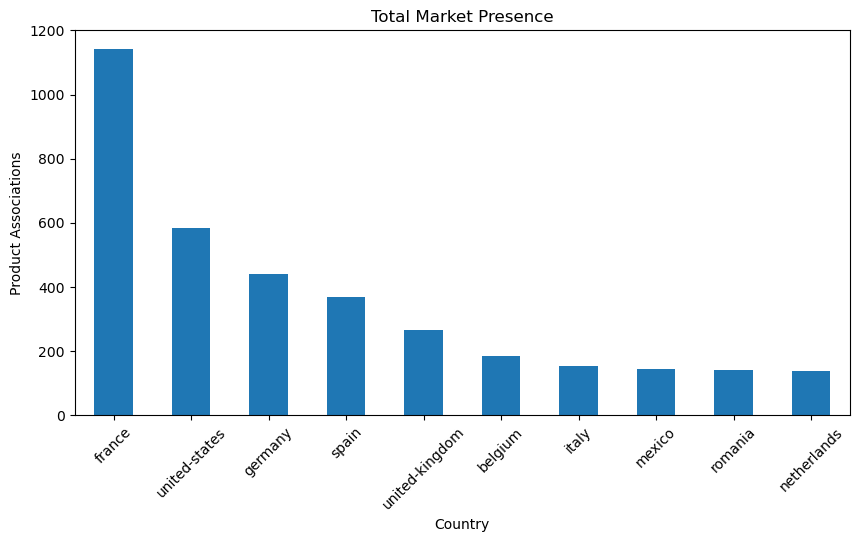


Observations:
• France has the highest recorded presence (1,143 product associations).
• 147 distinct markets are represented in the available data.


In [48]:
# Total Market Presence
df = cocacola

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if c.empty:
    print("Insufficient data: no usable country information available.")
else:
    counts = c.value_counts()
    counts.head(10).plot(kind="bar", figsize=(10,5), title="Total Market Presence")
    plt.xlabel("Country")
    plt.ylabel("Product Associations")
    plt.xticks(rotation=45)
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} has the highest recorded presence ({counts.iloc[0]:,} product associations).")
    print(f"• {c.nunique():,} distinct markets are represented in the available data.")

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

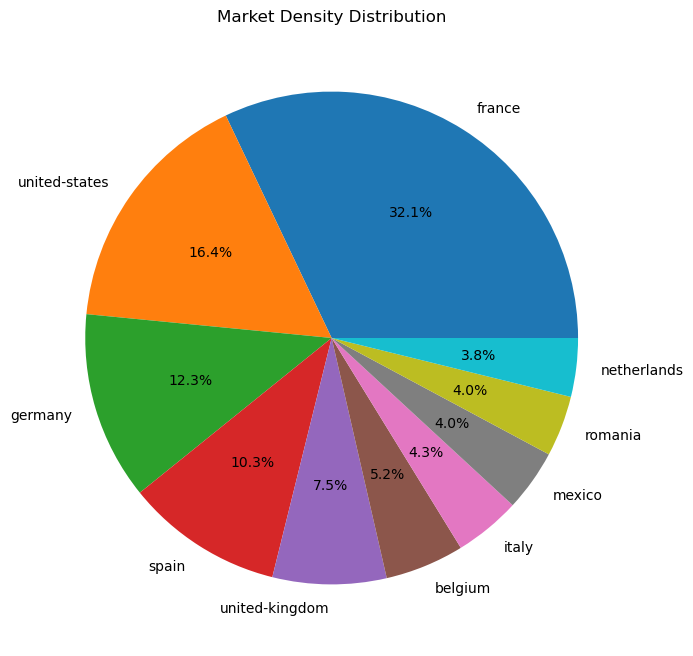


Observations:
• France has the largest share among the top recorded markets.
• The chart displays the top 10 markets only.


In [49]:
# Market Density Distribution
df = cocacola

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()
counts = c.value_counts().head(10)

if counts.empty:
    print("Insufficient data: no usable market information available.")
else:
    counts.plot(kind="pie", autopct="%1.1f%%", figsize=(8,8), title="Market Density Distribution")
    plt.ylabel("")
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} has the largest share among the top recorded markets.")
    print(f"• The chart displays the top {len(counts)} markets only.")

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

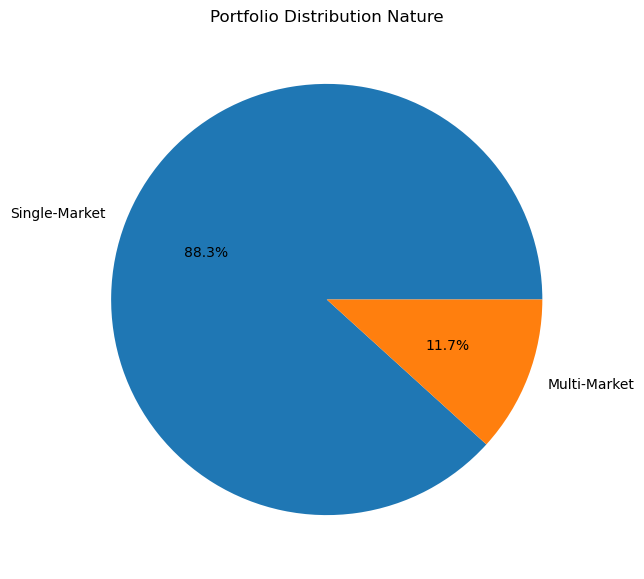


Observations:
• 88.3% of classifiable products are associated with one market.
• 11.7% are associated with multiple markets.


In [50]:
# Portfolio Distribution Nature
df = cocacola

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
c = c.explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if c.empty:
    print("Insufficient data: no usable country information available.")
else:
    n = c.groupby(c.index).nunique()
    # For duplicate indices, use row position instead.
    temp = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
    invalid = {"unknown", "n/a", "na", "none", "null", ""}

    def count_valid(values):
        if not isinstance(values, (list, tuple)):
            return 0
        return sum(
            pd.notna(value) and str(value).strip().lower() not in invalid
            for value in values
        )

    scope = temp.apply(count_valid)

    single = (scope == 1).sum()
    multi = (scope > 1).sum()

    if single + multi == 0:
        print("Insufficient data: products cannot be classified by market scope.")
    else:
        pd.Series({"Single-Market": single, "Multi-Market": multi}).plot(
            kind="pie", autopct="%1.1f%%", figsize=(7,7), title="Portfolio Distribution Nature"
        )
        plt.ylabel("")
        plt.show()

        print("\nObservations:")
        print(f"• {single/(single+multi)*100:.1f}% of classifiable products are associated with one market.")
        print(f"• {multi/(single+multi)*100:.1f}% are associated with multiple markets.")

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

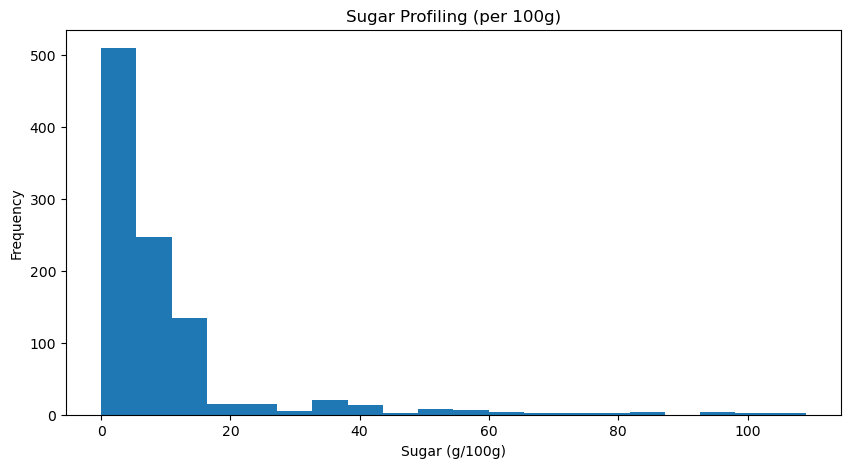


Observations:
• Mean sugar content is 9.01 g/100g.
• Median sugar content is 4.75 g/100g.
• Usable observations: 999.


In [51]:
# Sugar Profiling (Pre 100g)
df = cocacola

sugar = pd.to_numeric(df["nutriments.sugars_100g"], errors="coerce").dropna()

if sugar.empty:
    print("Insufficient data: no usable sugar observations available.")
else:
    sugar.plot(kind="hist", bins=20, figsize=(10,5), title="Sugar Profiling (per 100g)")
    plt.xlabel("Sugar (g/100g)")
    plt.show()

    print("\nObservations:")
    print(f"• Mean sugar content is {sugar.mean():.2f} g/100g.")
    print(f"• Median sugar content is {sugar.median():.2f} g/100g.")
    print(f"• Usable observations: {len(sugar):,}.")

##### Caloric Density

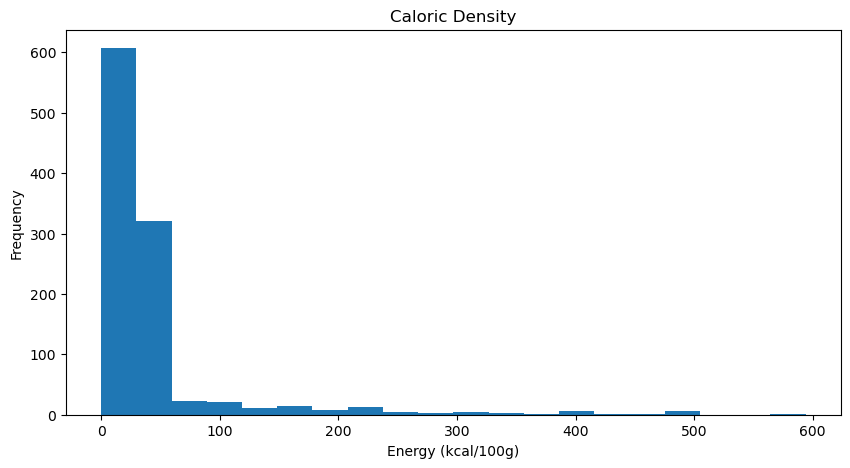


Observations:
• Mean energy density is 38.48 kcal/100g.
• Median energy density is 16.67 kcal/100g.
• Usable observations: 1,049.


In [52]:
# Caloric Density
df = cocacola

cal = pd.to_numeric(df["nutriments.energy-kcal_100g"], errors="coerce").dropna()

if cal.empty:
    print("Insufficient data: no usable calorie observations available.")
else:
    cal.plot(kind="hist", bins=20, figsize=(10,5), title="Caloric Density")
    plt.xlabel("Energy (kcal/100g)")
    plt.show()

    print("\nObservations:")
    print(f"• Mean energy density is {cal.mean():.2f} kcal/100g.")
    print(f"• Median energy density is {cal.median():.2f} kcal/100g.")
    print(f"• Usable observations: {len(cal):,}.")

##### Nutri-Score Rating

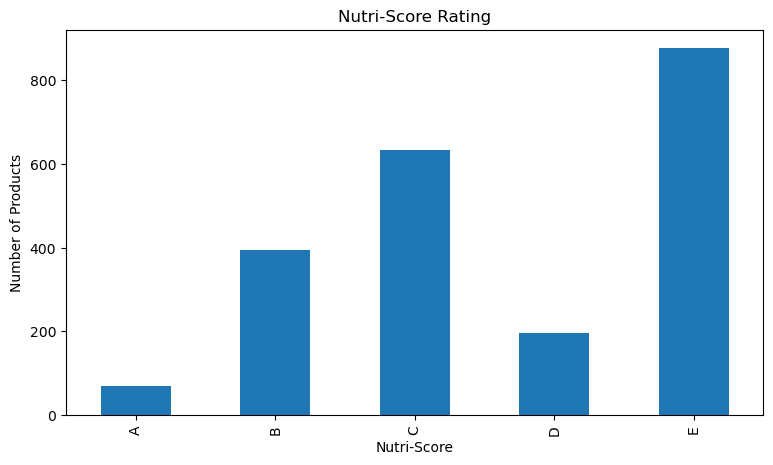


Observations:
• Grade E is the most frequent recorded Nutri-Score.
• 2,168 products have usable A–E Nutri-Score data.


In [53]:
# Nutri-Score Rating
df = cocacola

score = df["nutriscore_grade"].astype("string").str.strip().str.upper()
score = score[score.isin(["A", "B", "C", "D", "E"])]

if score.empty:
    print("Insufficient data: no usable Nutri-Score A–E observations available.")
else:
    counts = score.value_counts().reindex(["A","B","C","D","E"]).dropna()
    counts.plot(kind="bar", figsize=(9,5), title="Nutri-Score Rating")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• Grade {counts.idxmax()} is the most frequent recorded Nutri-Score.")
    print(f"• {len(score):,} products have usable A–E Nutri-Score data.")

#### 1.3 Formulation & Processing

##### NOVA Processing Level

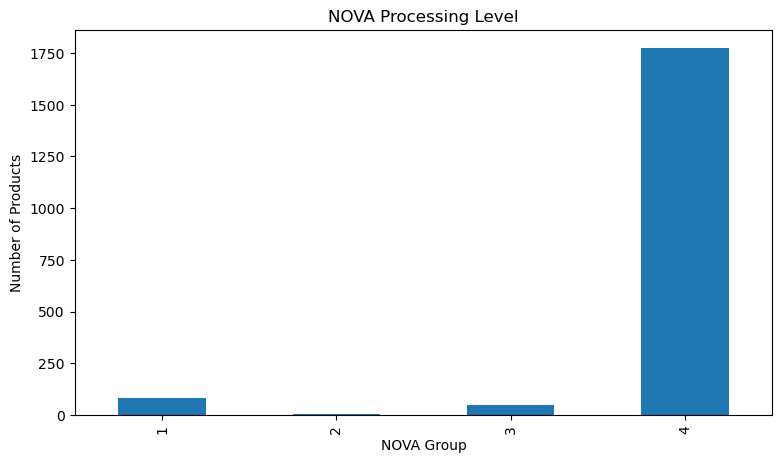


Observations:
• NOVA Group 4 is the most frequently recorded processing level.
• 1,905 products have usable NOVA Group 1–4 data.


In [54]:
# NOVA Processing Level
df = cocacola

nova = pd.to_numeric(df["nova_group"], errors="coerce").dropna()
nova = nova[nova.isin([1, 2, 3, 4])]

if nova.empty:
    print("Insufficient data: no usable NOVA Group 1–4 observations available.")
else:
    counts = nova.astype(int).value_counts().sort_index()
    counts.plot(kind="bar", figsize=(9,5), title="NOVA Processing Level")
    plt.xlabel("NOVA Group")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• NOVA Group {counts.idxmax()} is the most frequently recorded processing level.")
    print(f"• {len(nova):,} products have usable NOVA Group 1–4 data.")

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

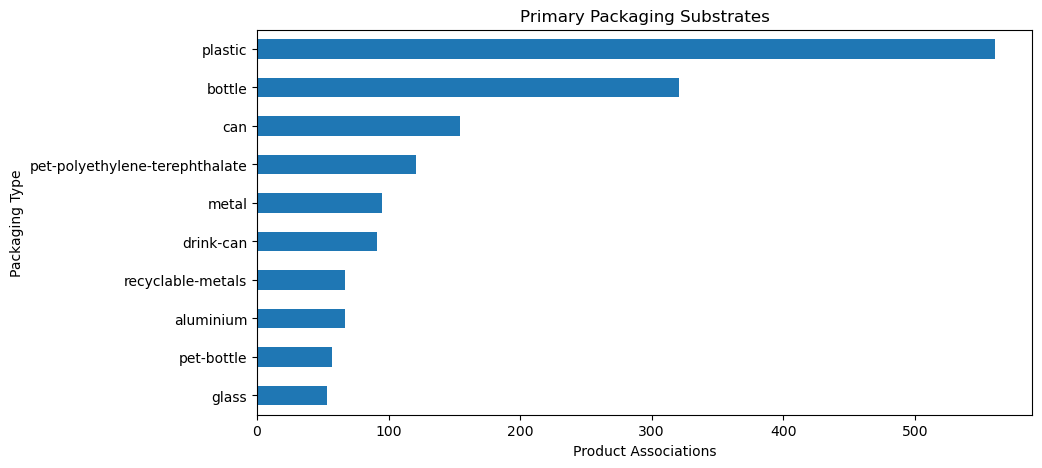


Observations:
• Plastic is the most frequently recorded packaging type.
• 2,473 usable packaging associations were analyzed.


In [55]:
# Primary Packaging Substrates
df = cocacola

p = df["packaging_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
p = p[~p.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if p.empty:
    print("Insufficient data: no usable packaging information available.")
else:
    counts = p.str.lower().value_counts().head(10)
    counts.sort_values().plot(kind="barh", figsize=(10,5), title="Primary Packaging Substrates")
    plt.xlabel("Product Associations")
    plt.ylabel("Packaging Type")
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} is the most frequently recorded packaging type.")
    print(f"• {len(p):,} usable packaging associations were analyzed.")

##### Environmental Data Transparency (Eco-Score)

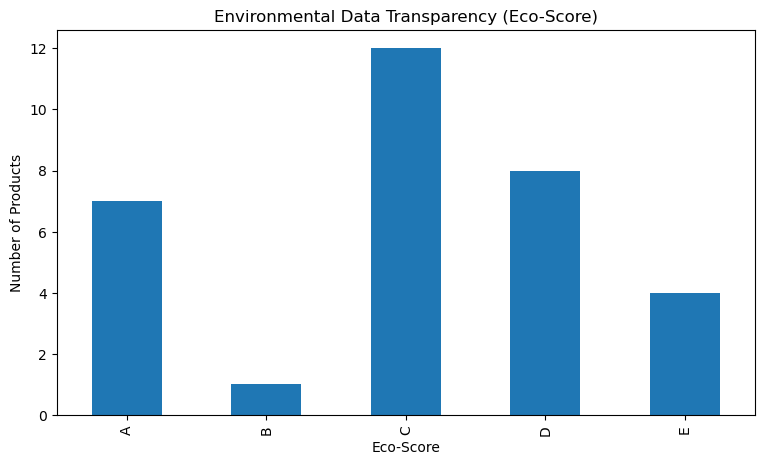


Observations:
• Grade C is the most frequently recorded Eco-Score.
• 32 products have usable A–E Eco-Score data.


In [56]:
# Environmental Data Transparency (Eco-Score)
df = cocacola

eco = df["ecoscore_grade"].astype("string").str.strip().str.upper()
eco = eco[eco.isin(["A", "B", "C", "D", "E"])]

if eco.empty:
    print("Insufficient data: no usable Eco-Score A–E observations available.")
else:
    counts = eco.value_counts().reindex(["A","B","C","D","E"]).dropna()
    counts.plot(kind="bar", figsize=(9,5), title="Environmental Data Transparency (Eco-Score)")
    plt.xlabel("Eco-Score")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• Grade {counts.idxmax()} is the most frequently recorded Eco-Score.")
    print(f"• {len(eco):,} products have usable A–E Eco-Score data.")

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

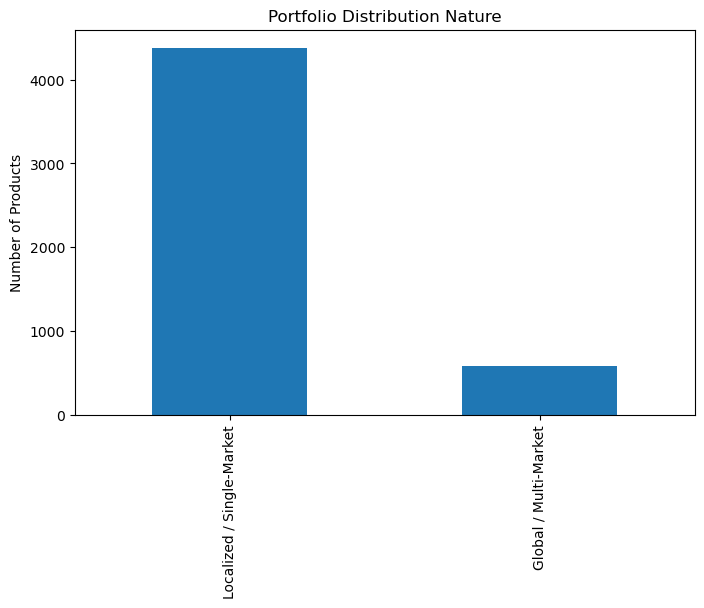


Observations:
• 88.3% of classifiable products are localized to one market.
• 11.7% are associated with multiple markets.


In [57]:
# Portfolio Distribution Nature — formulation scope
df = cocacola

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
invalid = {"unknown", "n/a", "na", "none", "null", ""}

scope = c.apply(
    lambda values: sum(
        pd.notna(v) and str(v).strip().lower() not in invalid
        for v in values
    )
    if isinstance(values, (list, tuple))
    else 0
)

single = (scope == 1).sum()
global_ = (scope > 1).sum()
total = single + global_

if total == 0:
    print("Insufficient data: no products have usable market-scope information.")
else:
    pd.Series({"Localized / Single-Market": single, "Global / Multi-Market": global_}).plot(
        kind="bar", figsize=(8,5), title="Portfolio Distribution Nature"
    )
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• {single/total*100:.1f}% of classifiable products are localized to one market.")
    print(f"• {global_/total*100:.1f}% are associated with multiple markets.")

### Brand: Fairlife

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Fanta

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

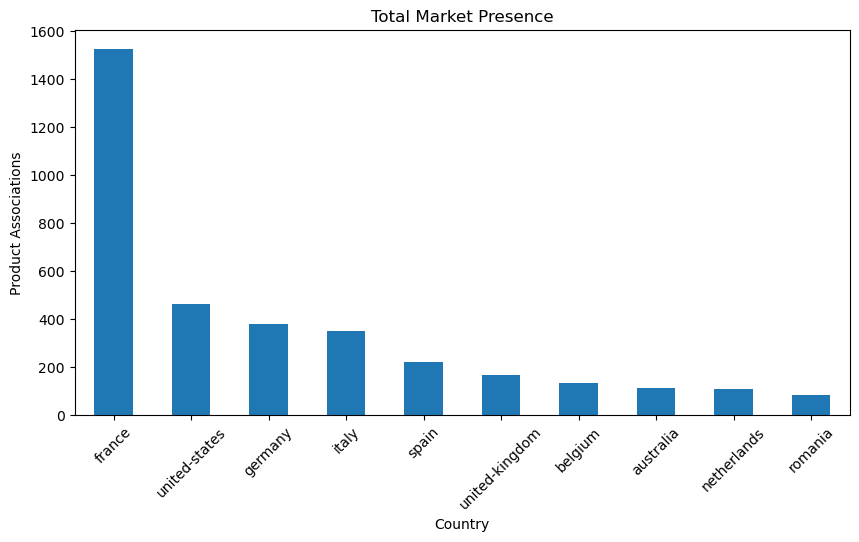


Observations:
• France has the highest recorded presence (1,528 product associations).
• 133 distinct markets are represented in the available data.


In [58]:
# Total Market Presence
df = fanta

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if c.empty:
    print("Insufficient data: no usable country information available.")
else:
    counts = c.value_counts()
    counts.head(10).plot(kind="bar", figsize=(10,5), title="Total Market Presence")
    plt.xlabel("Country")
    plt.ylabel("Product Associations")
    plt.xticks(rotation=45)
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} has the highest recorded presence ({counts.iloc[0]:,} product associations).")
    print(f"• {c.nunique():,} distinct markets are represented in the available data.")

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

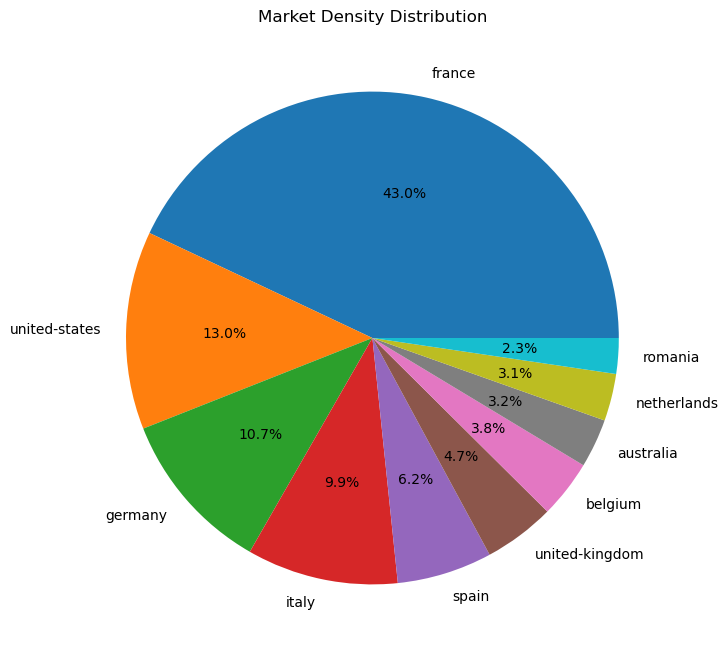


Observations:
• France has the largest share among the top recorded markets.
• The chart displays the top 10 markets only.


In [59]:
# Market Density Distribution
df = fanta

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()
counts = c.value_counts().head(10)

if counts.empty:
    print("Insufficient data: no usable market information available.")
else:
    counts.plot(kind="pie", autopct="%1.1f%%", figsize=(8,8), title="Market Density Distribution")
    plt.ylabel("")
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} has the largest share among the top recorded markets.")
    print(f"• The chart displays the top {len(counts)} markets only.")

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

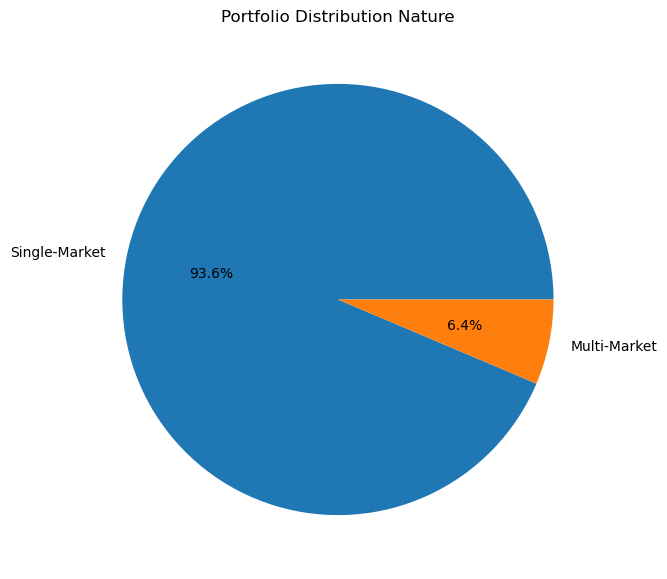


Observations:
• 93.6% of classifiable products are associated with one market.
• 6.4% are associated with multiple markets.


In [60]:
# Portfolio Distribution Nature
df = fanta

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
c = c.explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if c.empty:
    print("Insufficient data: no usable country information available.")
else:
    n = c.groupby(c.index).nunique()
    # For duplicate indices, use row position instead.
    temp = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
    invalid = {"unknown", "n/a", "na", "none", "null", ""}

    def count_valid(values):
        if not isinstance(values, (list, tuple)):
            return 0
        return sum(
            pd.notna(value) and str(value).strip().lower() not in invalid
            for value in values
        )

    scope = temp.apply(count_valid)

    single = (scope == 1).sum()
    multi = (scope > 1).sum()

    if single + multi == 0:
        print("Insufficient data: products cannot be classified by market scope.")
    else:
        pd.Series({"Single-Market": single, "Multi-Market": multi}).plot(
            kind="pie", autopct="%1.1f%%", figsize=(7,7), title="Portfolio Distribution Nature"
        )
        plt.ylabel("")
        plt.show()

        print("\nObservations:")
        print(f"• {single/(single+multi)*100:.1f}% of classifiable products are associated with one market.")
        print(f"• {multi/(single+multi)*100:.1f}% are associated with multiple markets.")

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

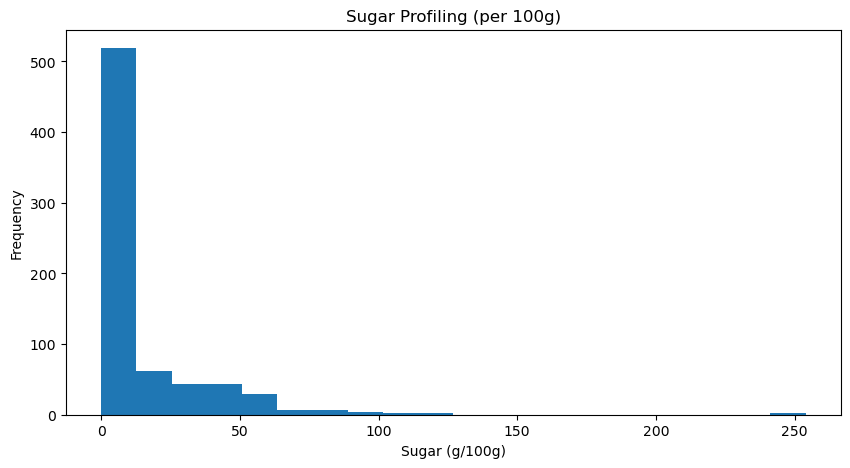


Observations:
• Mean sugar content is 13.96 g/100g.
• Median sugar content is 4.60 g/100g.
• Usable observations: 721.


In [61]:
# Sugar Profiling (Pre 100g)
df = fanta

sugar = pd.to_numeric(df["nutriments.sugars_100g"], errors="coerce").dropna()

if sugar.empty:
    print("Insufficient data: no usable sugar observations available.")
else:
    sugar.plot(kind="hist", bins=20, figsize=(10,5), title="Sugar Profiling (per 100g)")
    plt.xlabel("Sugar (g/100g)")
    plt.show()

    print("\nObservations:")
    print(f"• Mean sugar content is {sugar.mean():.2f} g/100g.")
    print(f"• Median sugar content is {sugar.median():.2f} g/100g.")
    print(f"• Usable observations: {len(sugar):,}.")

##### Caloric Density

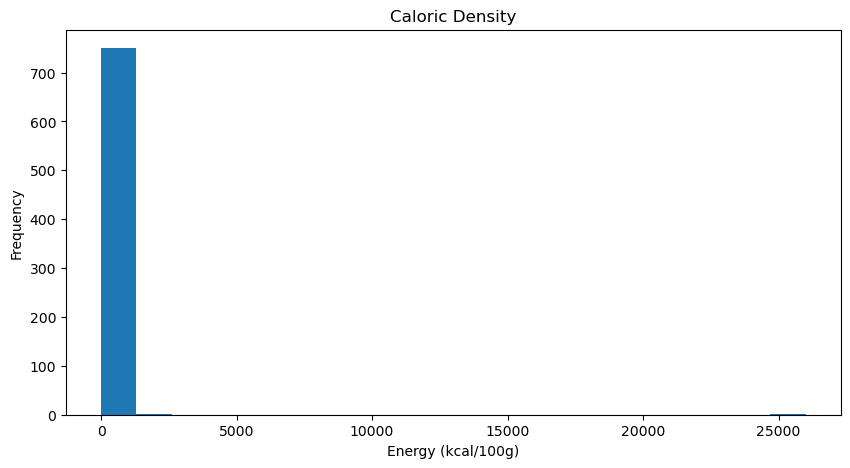


Observations:
• Mean energy density is 161.48 kcal/100g.
• Median energy density is 33.00 kcal/100g.
• Usable observations: 752.


In [62]:
# Caloric Density
df = fanta

cal = pd.to_numeric(df["nutriments.energy-kcal_100g"], errors="coerce").dropna()

if cal.empty:
    print("Insufficient data: no usable calorie observations available.")
else:
    cal.plot(kind="hist", bins=20, figsize=(10,5), title="Caloric Density")
    plt.xlabel("Energy (kcal/100g)")
    plt.show()

    print("\nObservations:")
    print(f"• Mean energy density is {cal.mean():.2f} kcal/100g.")
    print(f"• Median energy density is {cal.median():.2f} kcal/100g.")
    print(f"• Usable observations: {len(cal):,}.")

##### Nutri-Score Rating

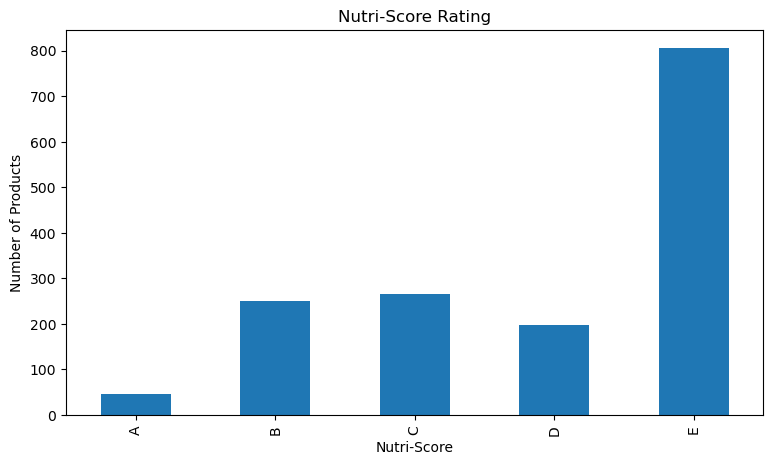


Observations:
• Grade E is the most frequent recorded Nutri-Score.
• 1,566 products have usable A–E Nutri-Score data.


In [63]:
# Nutri-Score Rating
df = fanta

score = df["nutriscore_grade"].astype("string").str.strip().str.upper()
score = score[score.isin(["A", "B", "C", "D", "E"])]

if score.empty:
    print("Insufficient data: no usable Nutri-Score A–E observations available.")
else:
    counts = score.value_counts().reindex(["A","B","C","D","E"]).dropna()
    counts.plot(kind="bar", figsize=(9,5), title="Nutri-Score Rating")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• Grade {counts.idxmax()} is the most frequent recorded Nutri-Score.")
    print(f"• {len(score):,} products have usable A–E Nutri-Score data.")

#### 1.3 Formulation & Processing

##### NOVA Processing Level

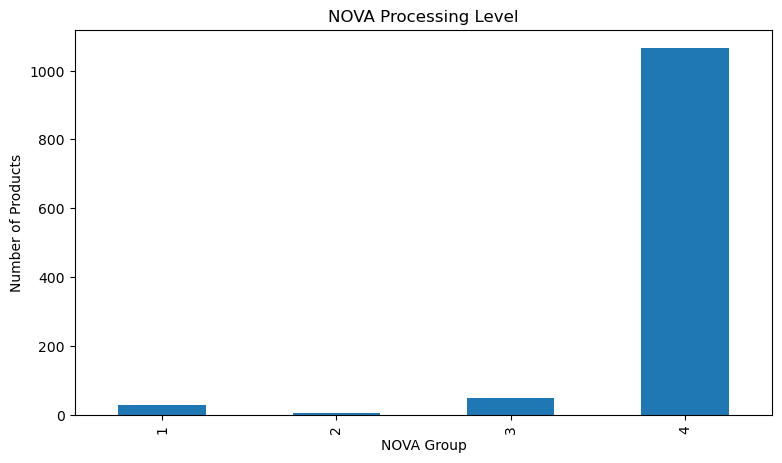


Observations:
• NOVA Group 4 is the most frequently recorded processing level.
• 1,145 products have usable NOVA Group 1–4 data.


In [64]:
# NOVA Processing Level
df = fanta

nova = pd.to_numeric(df["nova_group"], errors="coerce").dropna()
nova = nova[nova.isin([1, 2, 3, 4])]

if nova.empty:
    print("Insufficient data: no usable NOVA Group 1–4 observations available.")
else:
    counts = nova.astype(int).value_counts().sort_index()
    counts.plot(kind="bar", figsize=(9,5), title="NOVA Processing Level")
    plt.xlabel("NOVA Group")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• NOVA Group {counts.idxmax()} is the most frequently recorded processing level.")
    print(f"• {len(nova):,} products have usable NOVA Group 1–4 data.")

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

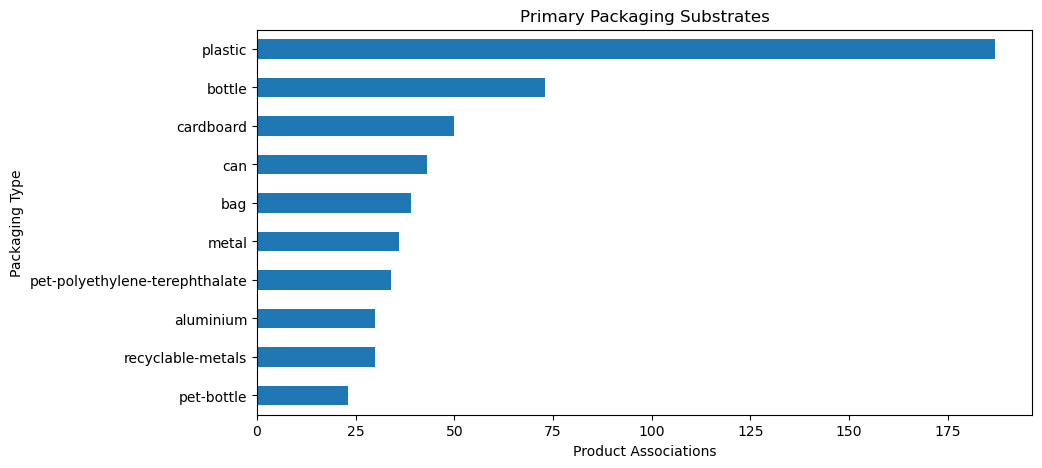


Observations:
• Plastic is the most frequently recorded packaging type.
• 951 usable packaging associations were analyzed.


In [65]:
# Primary Packaging Substrates
df = fanta

p = df["packaging_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
p = p[~p.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if p.empty:
    print("Insufficient data: no usable packaging information available.")
else:
    counts = p.str.lower().value_counts().head(10)
    counts.sort_values().plot(kind="barh", figsize=(10,5), title="Primary Packaging Substrates")
    plt.xlabel("Product Associations")
    plt.ylabel("Packaging Type")
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} is the most frequently recorded packaging type.")
    print(f"• {len(p):,} usable packaging associations were analyzed.")

##### Environmental Data Transparency (Eco-Score)

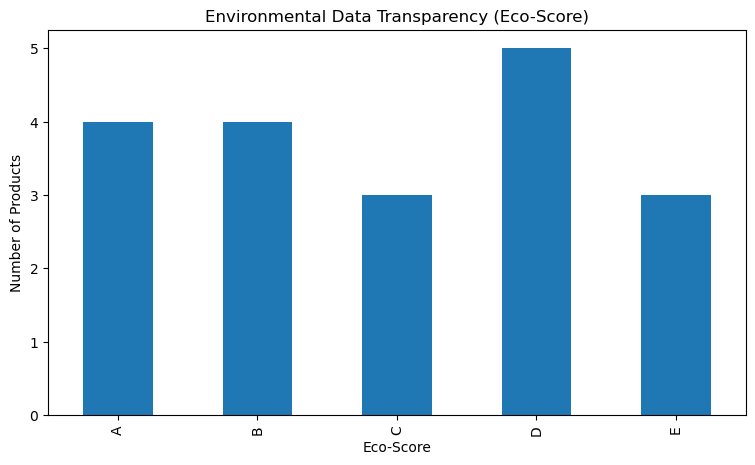


Observations:
• Grade D is the most frequently recorded Eco-Score.
• 19 products have usable A–E Eco-Score data.


In [66]:
# Environmental Data Transparency (Eco-Score)
df = fanta

eco = df["ecoscore_grade"].astype("string").str.strip().str.upper()
eco = eco[eco.isin(["A", "B", "C", "D", "E"])]

if eco.empty:
    print("Insufficient data: no usable Eco-Score A–E observations available.")
else:
    counts = eco.value_counts().reindex(["A","B","C","D","E"]).dropna()
    counts.plot(kind="bar", figsize=(9,5), title="Environmental Data Transparency (Eco-Score)")
    plt.xlabel("Eco-Score")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• Grade {counts.idxmax()} is the most frequently recorded Eco-Score.")
    print(f"• {len(eco):,} products have usable A–E Eco-Score data.")

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

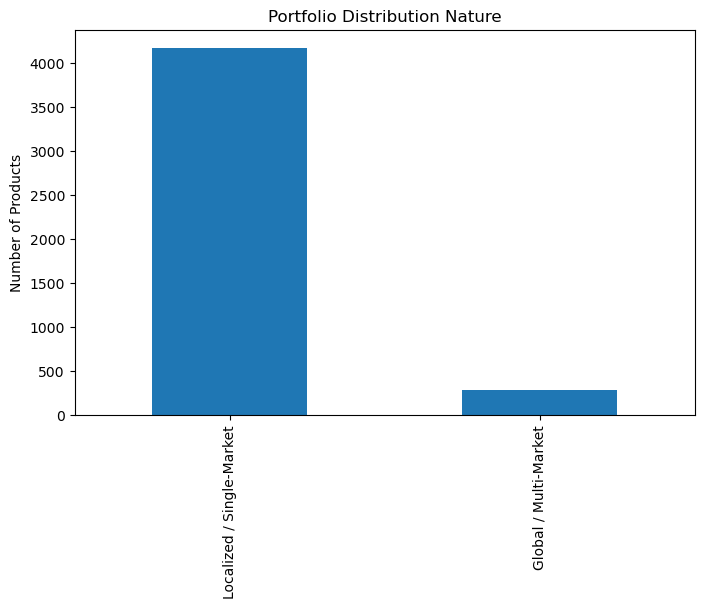


Observations:
• 93.6% of classifiable products are localized to one market.
• 6.4% are associated with multiple markets.


In [67]:
# Portfolio Distribution Nature — formulation scope
df = fanta

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
invalid = {"unknown", "n/a", "na", "none", "null", ""}

scope = c.apply(
    lambda values: sum(
        pd.notna(v) and str(v).strip().lower() not in invalid
        for v in values
    )
    if isinstance(values, (list, tuple))
    else 0
)

single = (scope == 1).sum()
global_ = (scope > 1).sum()
total = single + global_

if total == 0:
    print("Insufficient data: no products have usable market-scope information.")
else:
    pd.Series({"Localized / Single-Market": single, "Global / Multi-Market": global_}).plot(
        kind="bar", figsize=(8,5), title="Portfolio Distribution Nature"
    )
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• {single/total*100:.1f}% of classifiable products are localized to one market.")
    print(f"• {global_/total*100:.1f}% are associated with multiple markets.")

### Brand: Maaza

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

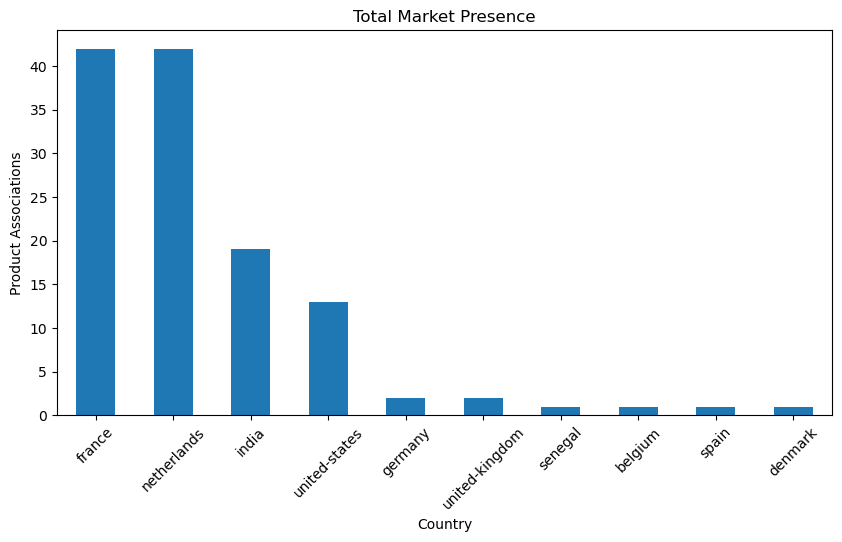


Observations:
• France has the highest recorded presence (42 product associations).
• 10 distinct markets are represented in the available data.


In [68]:
# Total Market Presence
df = maaza

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if c.empty:
    print("Insufficient data: no usable country information available.")
else:
    counts = c.value_counts()
    counts.head(10).plot(kind="bar", figsize=(10,5), title="Total Market Presence")
    plt.xlabel("Country")
    plt.ylabel("Product Associations")
    plt.xticks(rotation=45)
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} has the highest recorded presence ({counts.iloc[0]:,} product associations).")
    print(f"• {c.nunique():,} distinct markets are represented in the available data.")

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

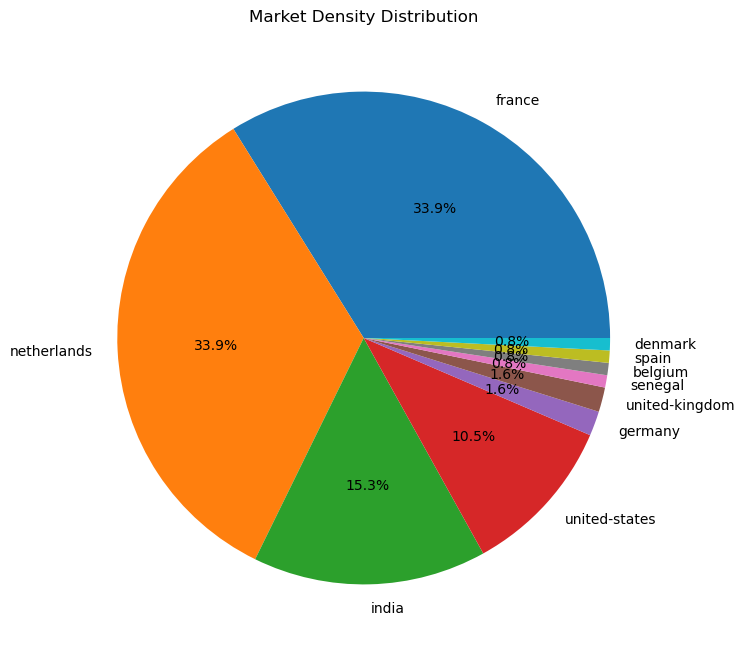


Observations:
• France has the largest share among the top recorded markets.
• The chart displays the top 10 markets only.


In [69]:
# Market Density Distribution
df = maaza

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()
counts = c.value_counts().head(10)

if counts.empty:
    print("Insufficient data: no usable market information available.")
else:
    counts.plot(kind="pie", autopct="%1.1f%%", figsize=(8,8), title="Market Density Distribution")
    plt.ylabel("")
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} has the largest share among the top recorded markets.")
    print(f"• The chart displays the top {len(counts)} markets only.")

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

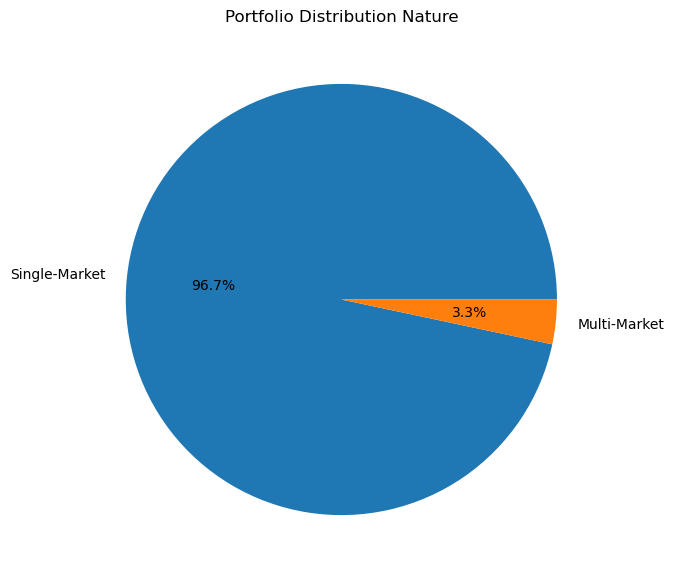


Observations:
• 96.7% of classifiable products are associated with one market.
• 3.3% are associated with multiple markets.


In [70]:
# Portfolio Distribution Nature
df = maaza

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
c = c.explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if c.empty:
    print("Insufficient data: no usable country information available.")
else:
    n = c.groupby(c.index).nunique()
    # For duplicate indices, use row position instead.
    temp = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
    invalid = {"unknown", "n/a", "na", "none", "null", ""}

    def count_valid(values):
        if not isinstance(values, (list, tuple)):
            return 0
        return sum(
            pd.notna(value) and str(value).strip().lower() not in invalid
            for value in values
        )

    scope = temp.apply(count_valid)

    single = (scope == 1).sum()
    multi = (scope > 1).sum()

    if single + multi == 0:
        print("Insufficient data: products cannot be classified by market scope.")
    else:
        pd.Series({"Single-Market": single, "Multi-Market": multi}).plot(
            kind="pie", autopct="%1.1f%%", figsize=(7,7), title="Portfolio Distribution Nature"
        )
        plt.ylabel("")
        plt.show()

        print("\nObservations:")
        print(f"• {single/(single+multi)*100:.1f}% of classifiable products are associated with one market.")
        print(f"• {multi/(single+multi)*100:.1f}% are associated with multiple markets.")

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

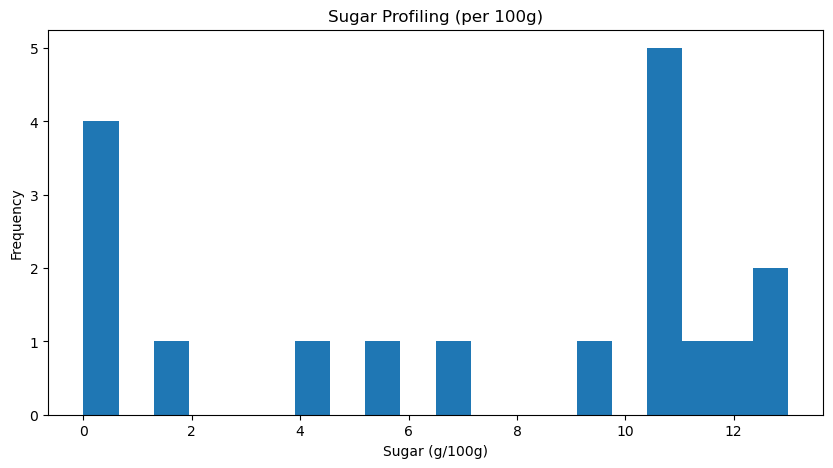


Observations:
• Mean sugar content is 7.22 g/100g.
• Median sugar content is 10.00 g/100g.
• Usable observations: 18.


In [71]:
# Sugar Profiling (Pre 100g)
df = maaza

sugar = pd.to_numeric(df["nutriments.sugars_100g"], errors="coerce").dropna()

if sugar.empty:
    print("Insufficient data: no usable sugar observations available.")
else:
    sugar.plot(kind="hist", bins=20, figsize=(10,5), title="Sugar Profiling (per 100g)")
    plt.xlabel("Sugar (g/100g)")
    plt.show()

    print("\nObservations:")
    print(f"• Mean sugar content is {sugar.mean():.2f} g/100g.")
    print(f"• Median sugar content is {sugar.median():.2f} g/100g.")
    print(f"• Usable observations: {len(sugar):,}.")

##### Caloric Density

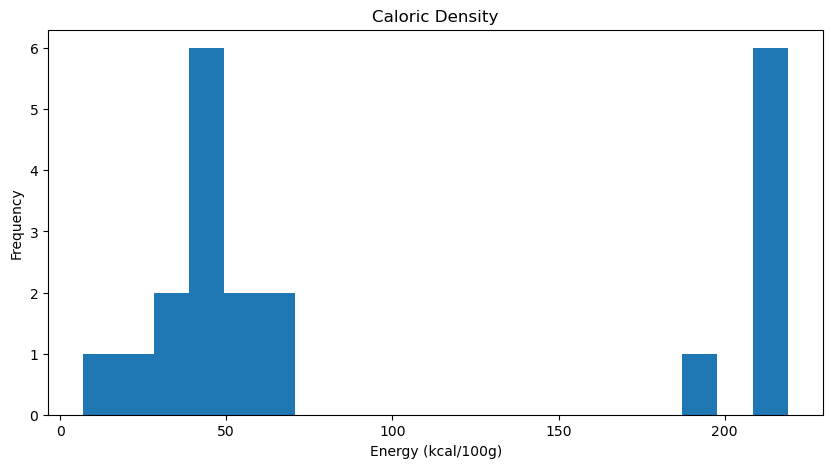


Observations:
• Mean energy density is 99.15 kcal/100g.
• Median energy density is 50.00 kcal/100g.
• Usable observations: 21.


In [72]:
# Caloric Density
df = maaza

cal = pd.to_numeric(df["nutriments.energy-kcal_100g"], errors="coerce").dropna()

if cal.empty:
    print("Insufficient data: no usable calorie observations available.")
else:
    cal.plot(kind="hist", bins=20, figsize=(10,5), title="Caloric Density")
    plt.xlabel("Energy (kcal/100g)")
    plt.show()

    print("\nObservations:")
    print(f"• Mean energy density is {cal.mean():.2f} kcal/100g.")
    print(f"• Median energy density is {cal.median():.2f} kcal/100g.")
    print(f"• Usable observations: {len(cal):,}.")

##### Nutri-Score Rating

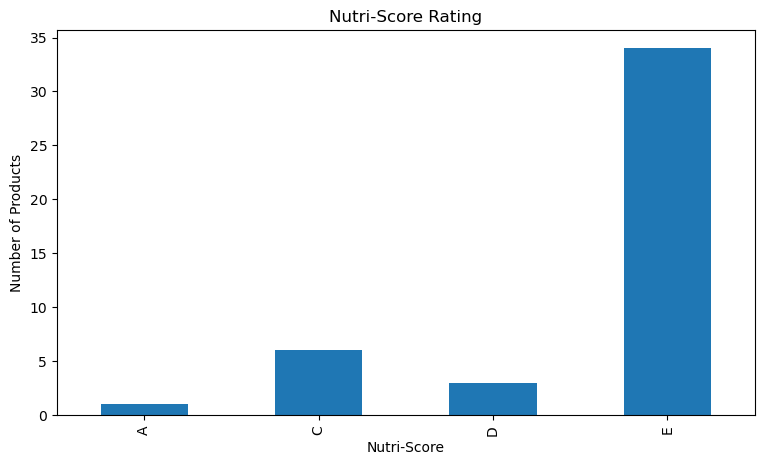


Observations:
• Grade E is the most frequent recorded Nutri-Score.
• 44 products have usable A–E Nutri-Score data.


In [73]:
# Nutri-Score Rating
df = maaza

score = df["nutriscore_grade"].astype("string").str.strip().str.upper()
score = score[score.isin(["A", "B", "C", "D", "E"])]

if score.empty:
    print("Insufficient data: no usable Nutri-Score A–E observations available.")
else:
    counts = score.value_counts().reindex(["A","B","C","D","E"]).dropna()
    counts.plot(kind="bar", figsize=(9,5), title="Nutri-Score Rating")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• Grade {counts.idxmax()} is the most frequent recorded Nutri-Score.")
    print(f"• {len(score):,} products have usable A–E Nutri-Score data.")

#### 1.3 Formulation & Processing

##### NOVA Processing Level

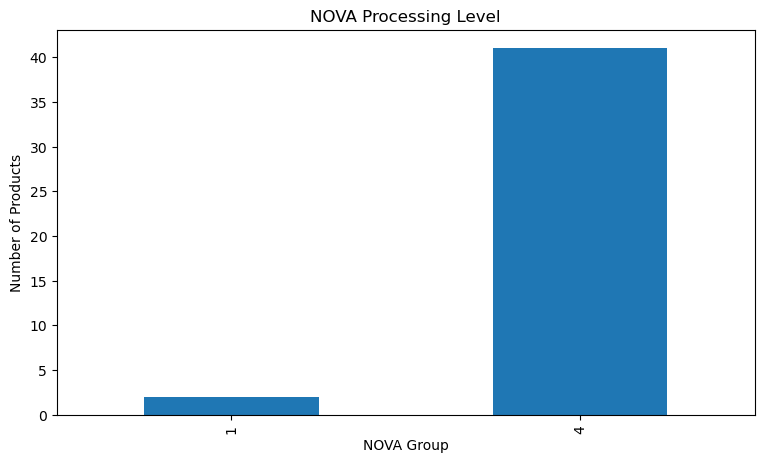


Observations:
• NOVA Group 4 is the most frequently recorded processing level.
• 43 products have usable NOVA Group 1–4 data.


In [74]:
# NOVA Processing Level
df = maaza

nova = pd.to_numeric(df["nova_group"], errors="coerce").dropna()
nova = nova[nova.isin([1, 2, 3, 4])]

if nova.empty:
    print("Insufficient data: no usable NOVA Group 1–4 observations available.")
else:
    counts = nova.astype(int).value_counts().sort_index()
    counts.plot(kind="bar", figsize=(9,5), title="NOVA Processing Level")
    plt.xlabel("NOVA Group")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• NOVA Group {counts.idxmax()} is the most frequently recorded processing level.")
    print(f"• {len(nova):,} products have usable NOVA Group 1–4 data.")

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

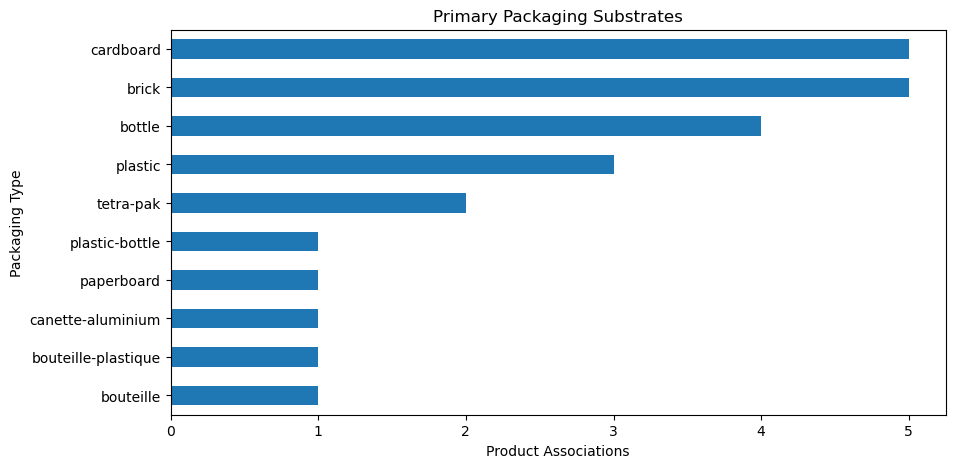


Observations:
• Brick is the most frequently recorded packaging type.
• 26 usable packaging associations were analyzed.


In [75]:
# Primary Packaging Substrates
df = maaza

p = df["packaging_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
p = p[~p.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if p.empty:
    print("Insufficient data: no usable packaging information available.")
else:
    counts = p.str.lower().value_counts().head(10)
    counts.sort_values().plot(kind="barh", figsize=(10,5), title="Primary Packaging Substrates")
    plt.xlabel("Product Associations")
    plt.ylabel("Packaging Type")
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} is the most frequently recorded packaging type.")
    print(f"• {len(p):,} usable packaging associations were analyzed.")

##### Environmental Data Transparency (Eco-Score)

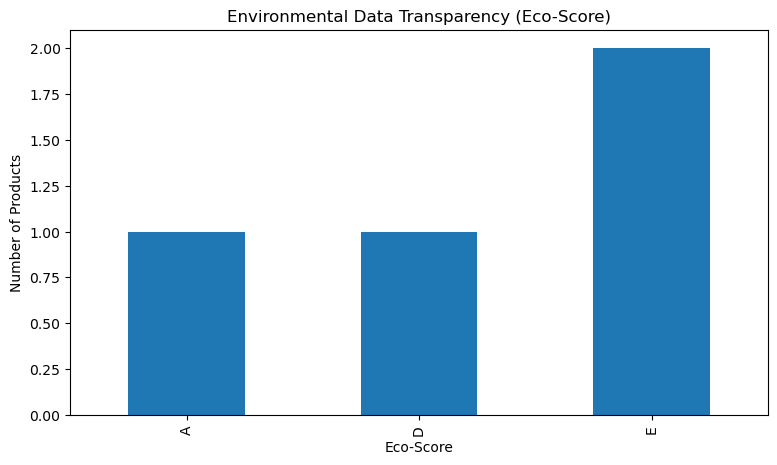


Observations:
• Grade E is the most frequently recorded Eco-Score.
• 4 products have usable A–E Eco-Score data.


In [76]:
# Environmental Data Transparency (Eco-Score)
df = maaza

eco = df["ecoscore_grade"].astype("string").str.strip().str.upper()
eco = eco[eco.isin(["A", "B", "C", "D", "E"])]

if eco.empty:
    print("Insufficient data: no usable Eco-Score A–E observations available.")
else:
    counts = eco.value_counts().reindex(["A","B","C","D","E"]).dropna()
    counts.plot(kind="bar", figsize=(9,5), title="Environmental Data Transparency (Eco-Score)")
    plt.xlabel("Eco-Score")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• Grade {counts.idxmax()} is the most frequently recorded Eco-Score.")
    print(f"• {len(eco):,} products have usable A–E Eco-Score data.")

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

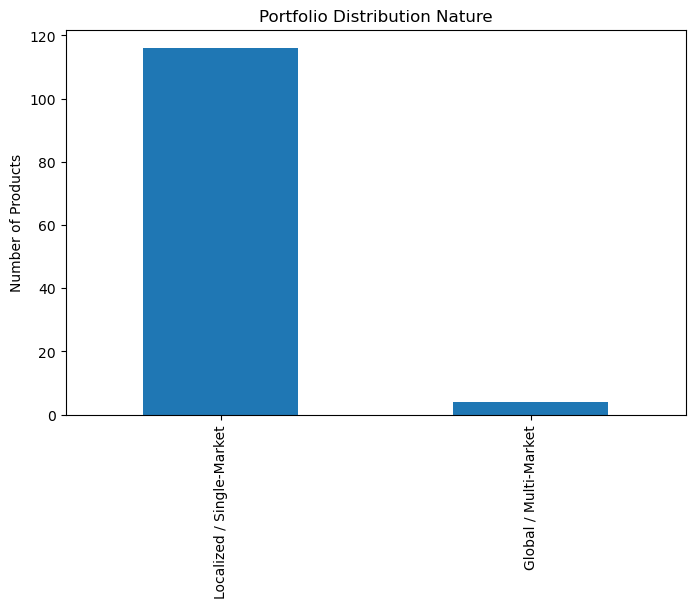


Observations:
• 96.7% of classifiable products are localized to one market.
• 3.3% are associated with multiple markets.


In [77]:
# Portfolio Distribution Nature — formulation scope
df = maaza

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
invalid = {"unknown", "n/a", "na", "none", "null", ""}

scope = c.apply(
    lambda values: sum(
        pd.notna(v) and str(v).strip().lower() not in invalid
        for v in values
    )
    if isinstance(values, (list, tuple))
    else 0
)

single = (scope == 1).sum()
global_ = (scope > 1).sum()
total = single + global_

if total == 0:
    print("Insufficient data: no products have usable market-scope information.")
else:
    pd.Series({"Localized / Single-Market": single, "Global / Multi-Market": global_}).plot(
        kind="bar", figsize=(8,5), title="Portfolio Distribution Nature"
    )
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• {single/total*100:.1f}% of classifiable products are localized to one market.")
    print(f"• {global_/total*100:.1f}% are associated with multiple markets.")

### Brand: Minute-Maid

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Schweppes

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Sprite

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Topo Chico

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

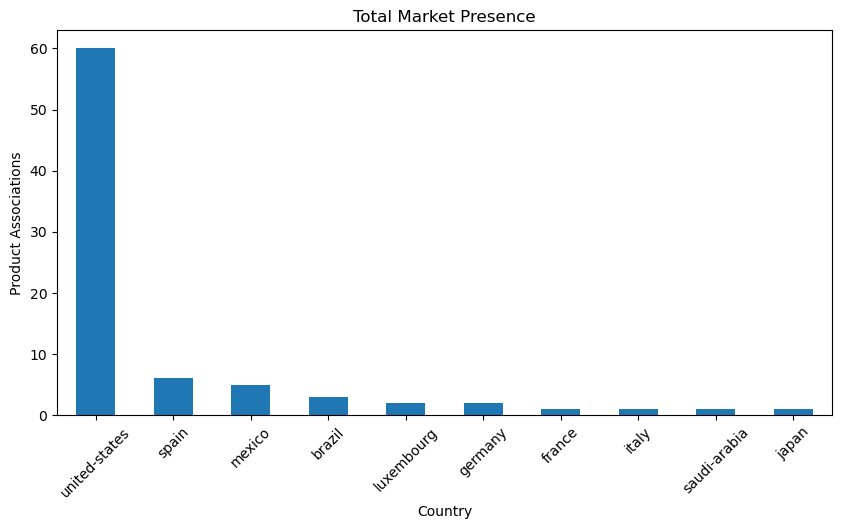


Observations:
• United-States has the highest recorded presence (60 product associations).
• 10 distinct markets are represented in the available data.


In [78]:
# Total Market Presence
df = topochico

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if c.empty:
    print("Insufficient data: no usable country information available.")
else:
    counts = c.value_counts()
    counts.head(10).plot(kind="bar", figsize=(10,5), title="Total Market Presence")
    plt.xlabel("Country")
    plt.ylabel("Product Associations")
    plt.xticks(rotation=45)
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} has the highest recorded presence ({counts.iloc[0]:,} product associations).")
    print(f"• {c.nunique():,} distinct markets are represented in the available data.")

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

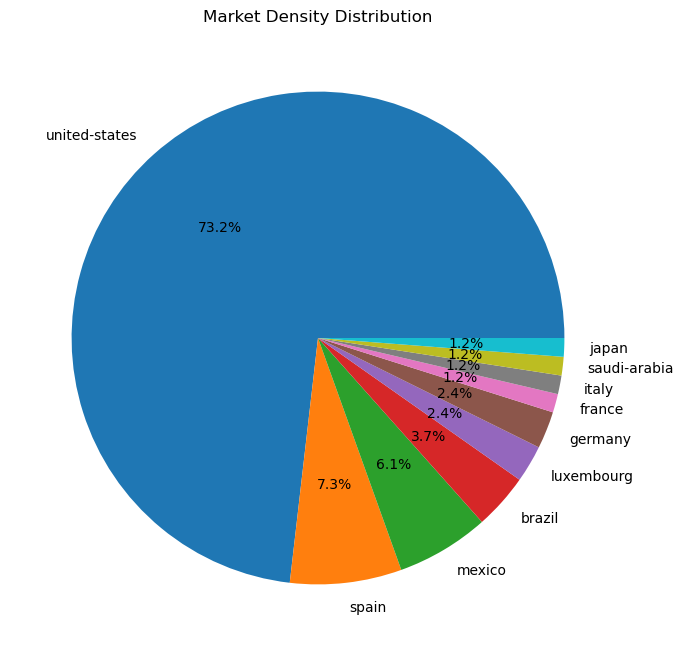


Observations:
• United-States has the largest share among the top recorded markets.
• The chart displays the top 10 markets only.


In [79]:
# Market Density Distribution
df = topochico

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()
counts = c.value_counts().head(10)

if counts.empty:
    print("Insufficient data: no usable market information available.")
else:
    counts.plot(kind="pie", autopct="%1.1f%%", figsize=(8,8), title="Market Density Distribution")
    plt.ylabel("")
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} has the largest share among the top recorded markets.")
    print(f"• The chart displays the top {len(counts)} markets only.")

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

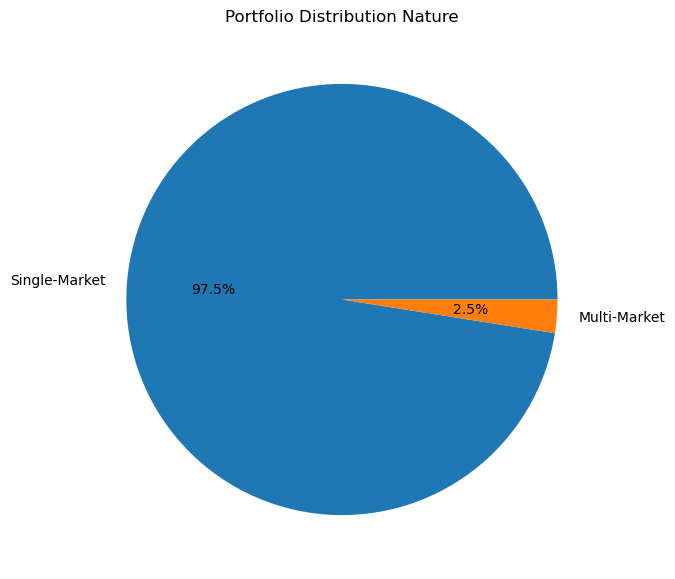


Observations:
• 97.5% of classifiable products are associated with one market.
• 2.5% are associated with multiple markets.


In [80]:
# Portfolio Distribution Nature
df = topochico

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
c = c.explode().str.strip()
c = c[~c.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if c.empty:
    print("Insufficient data: no usable country information available.")
else:
    n = c.groupby(c.index).nunique()
    # For duplicate indices, use row position instead.
    temp = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
    invalid = {"unknown", "n/a", "na", "none", "null", ""}

    def count_valid(values):
        if not isinstance(values, (list, tuple)):
            return 0
        return sum(
            pd.notna(value) and str(value).strip().lower() not in invalid
            for value in values
        )

    scope = temp.apply(count_valid)

    single = (scope == 1).sum()
    multi = (scope > 1).sum()

    if single + multi == 0:
        print("Insufficient data: products cannot be classified by market scope.")
    else:
        pd.Series({"Single-Market": single, "Multi-Market": multi}).plot(
            kind="pie", autopct="%1.1f%%", figsize=(7,7), title="Portfolio Distribution Nature"
        )
        plt.ylabel("")
        plt.show()

        print("\nObservations:")
        print(f"• {single/(single+multi)*100:.1f}% of classifiable products are associated with one market.")
        print(f"• {multi/(single+multi)*100:.1f}% are associated with multiple markets.")

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

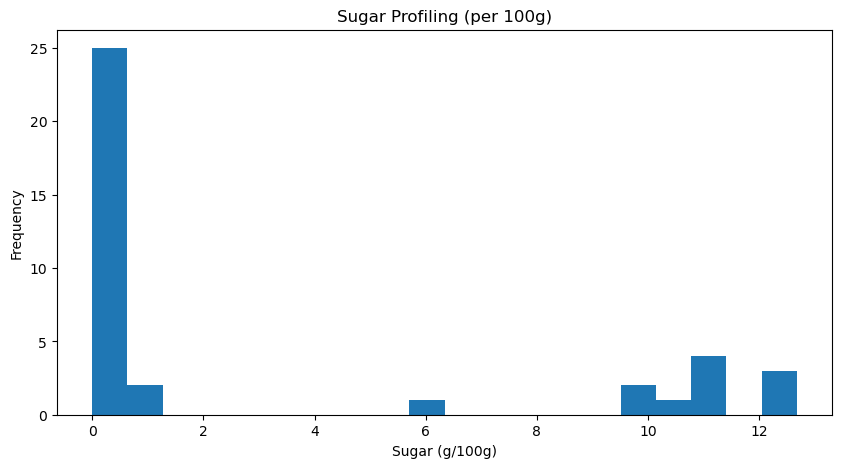


Observations:
• Mean sugar content is 3.25 g/100g.
• Median sugar content is 0.28 g/100g.
• Usable observations: 38.


In [81]:
# Sugar Profiling (Pre 100g)
df = topochico

sugar = pd.to_numeric(df["nutriments.sugars_100g"], errors="coerce").dropna()

if sugar.empty:
    print("Insufficient data: no usable sugar observations available.")
else:
    sugar.plot(kind="hist", bins=20, figsize=(10,5), title="Sugar Profiling (per 100g)")
    plt.xlabel("Sugar (g/100g)")
    plt.show()

    print("\nObservations:")
    print(f"• Mean sugar content is {sugar.mean():.2f} g/100g.")
    print(f"• Median sugar content is {sugar.median():.2f} g/100g.")
    print(f"• Usable observations: {len(sugar):,}.")

##### Caloric Density

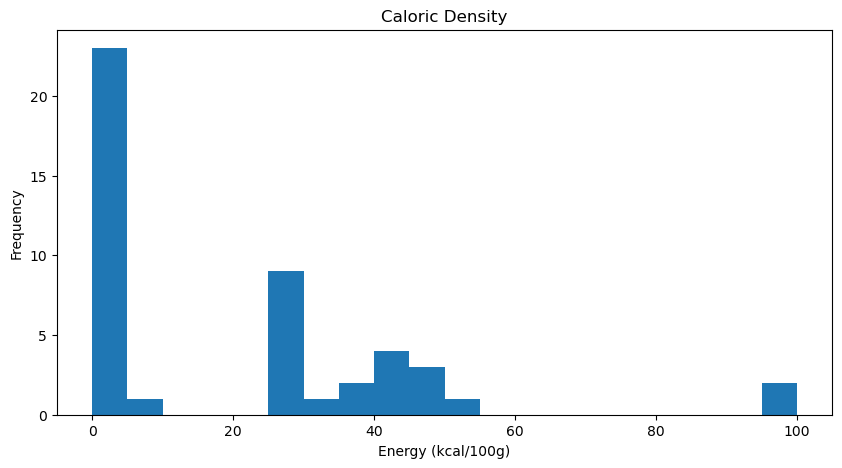


Observations:
• Mean energy density is 20.71 kcal/100g.
• Median energy density is 3.91 kcal/100g.
• Usable observations: 46.


In [82]:
# Caloric Density
df = topochico

cal = pd.to_numeric(df["nutriments.energy-kcal_100g"], errors="coerce").dropna()

if cal.empty:
    print("Insufficient data: no usable calorie observations available.")
else:
    cal.plot(kind="hist", bins=20, figsize=(10,5), title="Caloric Density")
    plt.xlabel("Energy (kcal/100g)")
    plt.show()

    print("\nObservations:")
    print(f"• Mean energy density is {cal.mean():.2f} kcal/100g.")
    print(f"• Median energy density is {cal.median():.2f} kcal/100g.")
    print(f"• Usable observations: {len(cal):,}.")

##### Nutri-Score Rating

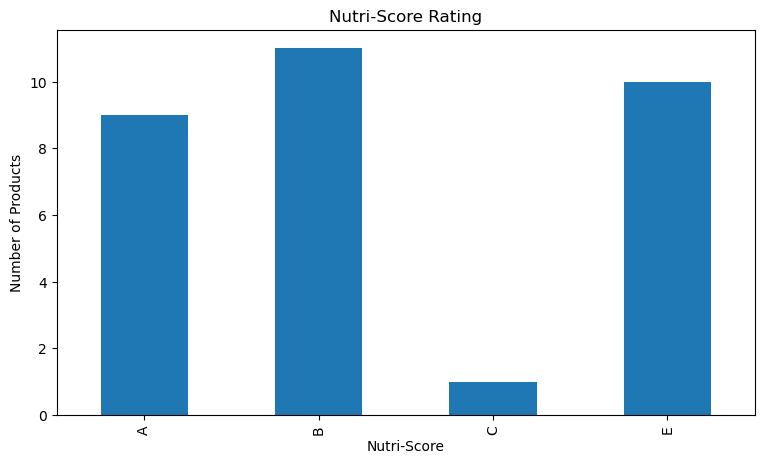


Observations:
• Grade B is the most frequent recorded Nutri-Score.
• 31 products have usable A–E Nutri-Score data.


In [83]:
# Nutri-Score Rating
df = topochico

score = df["nutriscore_grade"].astype("string").str.strip().str.upper()
score = score[score.isin(["A", "B", "C", "D", "E"])]

if score.empty:
    print("Insufficient data: no usable Nutri-Score A–E observations available.")
else:
    counts = score.value_counts().reindex(["A","B","C","D","E"]).dropna()
    counts.plot(kind="bar", figsize=(9,5), title="Nutri-Score Rating")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• Grade {counts.idxmax()} is the most frequent recorded Nutri-Score.")
    print(f"• {len(score):,} products have usable A–E Nutri-Score data.")

#### 1.3 Formulation & Processing

##### NOVA Processing Level

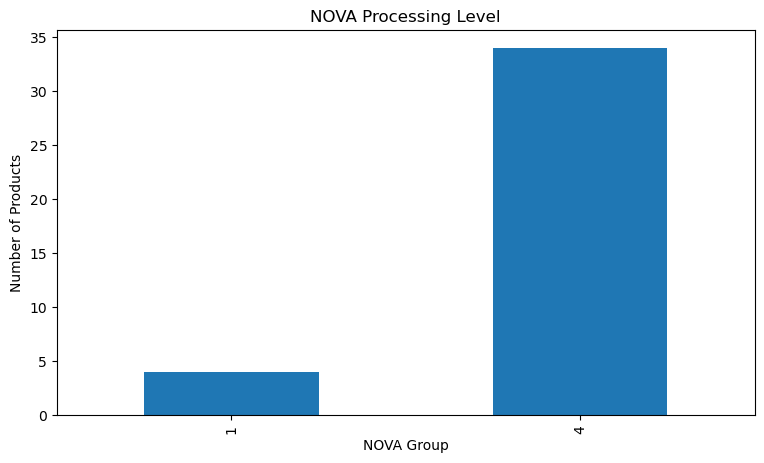


Observations:
• NOVA Group 4 is the most frequently recorded processing level.
• 38 products have usable NOVA Group 1–4 data.


In [84]:
# NOVA Processing Level
df = topochico

nova = pd.to_numeric(df["nova_group"], errors="coerce").dropna()
nova = nova[nova.isin([1, 2, 3, 4])]

if nova.empty:
    print("Insufficient data: no usable NOVA Group 1–4 observations available.")
else:
    counts = nova.astype(int).value_counts().sort_index()
    counts.plot(kind="bar", figsize=(9,5), title="NOVA Processing Level")
    plt.xlabel("NOVA Group")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• NOVA Group {counts.idxmax()} is the most frequently recorded processing level.")
    print(f"• {len(nova):,} products have usable NOVA Group 1–4 data.")

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

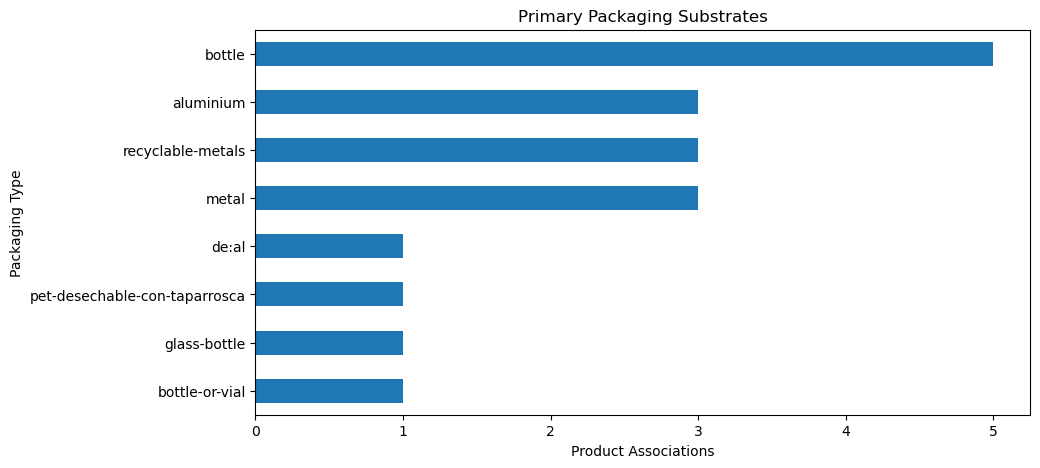


Observations:
• Bottle is the most frequently recorded packaging type.
• 18 usable packaging associations were analyzed.


In [85]:
# Primary Packaging Substrates
df = topochico

p = df["packaging_tags"].astype("string").str.replace(";", ",").str.split(",").explode().str.strip()
p = p[~p.str.lower().isin(["unknown", "n/a", "na", "none", "null", ""])].dropna()

if p.empty:
    print("Insufficient data: no usable packaging information available.")
else:
    counts = p.str.lower().value_counts().head(10)
    counts.sort_values().plot(kind="barh", figsize=(10,5), title="Primary Packaging Substrates")
    plt.xlabel("Product Associations")
    plt.ylabel("Packaging Type")
    plt.show()

    print("\nObservations:")
    print(f"• {counts.index[0].title()} is the most frequently recorded packaging type.")
    print(f"• {len(p):,} usable packaging associations were analyzed.")

##### Environmental Data Transparency (Eco-Score)

In [86]:
# Environmental Data Transparency (Eco-Score)
df = topochico

eco = df["ecoscore_grade"].astype("string").str.strip().str.upper()
eco = eco[eco.isin(["A", "B", "C", "D", "E"])]

if eco.empty:
    print("Insufficient data: no usable Eco-Score A–E observations available.")
else:
    counts = eco.value_counts().reindex(["A","B","C","D","E"]).dropna()
    counts.plot(kind="bar", figsize=(9,5), title="Environmental Data Transparency (Eco-Score)")
    plt.xlabel("Eco-Score")
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• Grade {counts.idxmax()} is the most frequently recorded Eco-Score.")
    print(f"• {len(eco):,} products have usable A–E Eco-Score data.")

Insufficient data: no usable Eco-Score A–E observations available.


##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

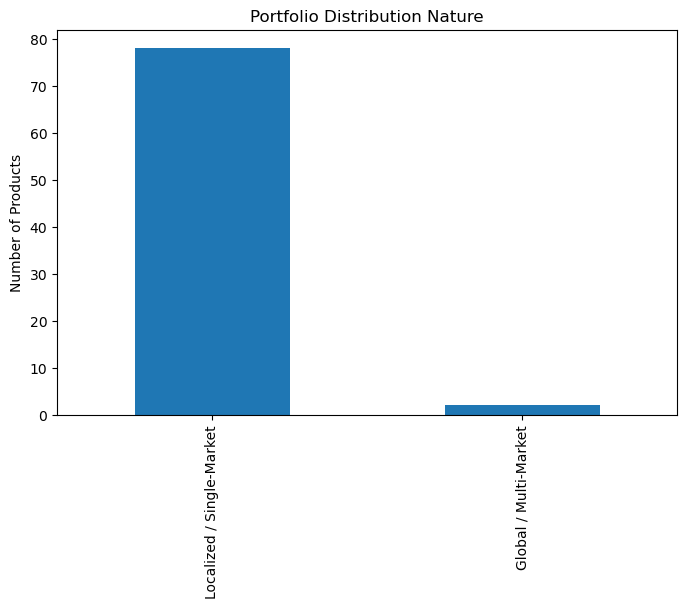


Observations:
• 97.5% of classifiable products are localized to one market.
• 2.5% are associated with multiple markets.


In [87]:
# Portfolio Distribution Nature — formulation scope
df = topochico

c = df["countries_tags"].astype("string").str.replace(";", ",").str.split(",")
invalid = {"unknown", "n/a", "na", "none", "null", ""}

scope = c.apply(
    lambda values: sum(
        pd.notna(v) and str(v).strip().lower() not in invalid
        for v in values
    )
    if isinstance(values, (list, tuple))
    else 0
)

single = (scope == 1).sum()
global_ = (scope > 1).sum()
total = single + global_

if total == 0:
    print("Insufficient data: no products have usable market-scope information.")
else:
    pd.Series({"Localized / Single-Market": single, "Global / Multi-Market": global_}).plot(
        kind="bar", figsize=(8,5), title="Portfolio Distribution Nature"
    )
    plt.ylabel("Number of Products")
    plt.show()

    print("\nObservations:")
    print(f"• {single/total*100:.1f}% of classifiable products are localized to one market.")
    print(f"• {global_/total*100:.1f}% are associated with multiple markets.")

## Section 2: Geographic Overview
Catalog Variations across Various Countries

### Brand: Coca-Cola

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Fairlife

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Fanta

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Maaza

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Minute Maid

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Schweppes

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Sprite

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Topo Chico

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

## Section 3: Health & Nutrition Differences Across Regions

### Brand: Coca-Cola

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Fairlife

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Fanta

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Maaza

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Minute Maid

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Schweppes

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Sprite

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Topo Chico

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

## Section 4: Formulation & Processing Across Regions

### Brand: Coca-Cola

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Fairlife

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Fanta

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Maaza

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Minute Maid

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Schweppes

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Sprite

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Topo Chico

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

## Section 5: Packaging Preferences Across Regions

### Brand: Coca-Cola

#### 5.1 Material Preferences by Territory

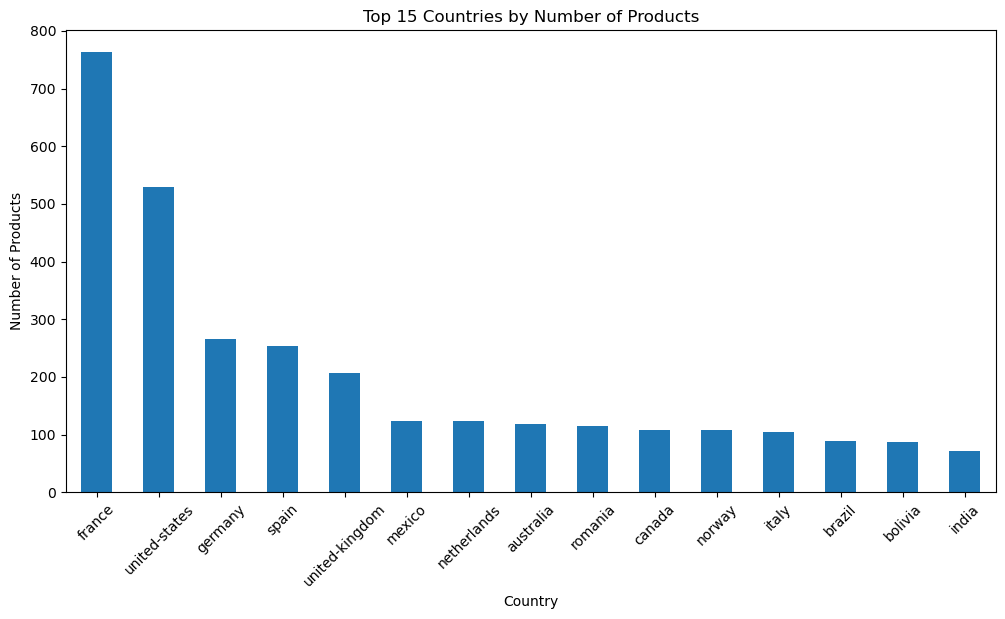

In [88]:
import matplotlib.pyplot as plt

country = cocacola['countries_tags'].value_counts().head(15)

plt.figure(figsize=(12,6))
country.plot(kind='bar')
plt.title('Top 15 Countries by Number of Products')
plt.xlabel('Country')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

### Observation

**Background:** Country counts are based on the country tags associated with products. A product may have multiple country tags, so the country-level table represents market associations rather than a one-product-one-country structure.

**Finding:** France has the largest representation with **1,143 products**, followed by the United States (**584 records in the original country count**), Germany (**440**), Spain (**368**), and the United Kingdom (**266**).

**What this means:** The available data is geographically uneven, with particularly strong representation from European markets.

**Why it matters for sectional analysis:** Country comparisons should account for this imbalance. France has far more observations than many other countries, so its patterns are more strongly represented in the dataset.

#### 5.2 Regional Sustainability & Reporting Discrepancies

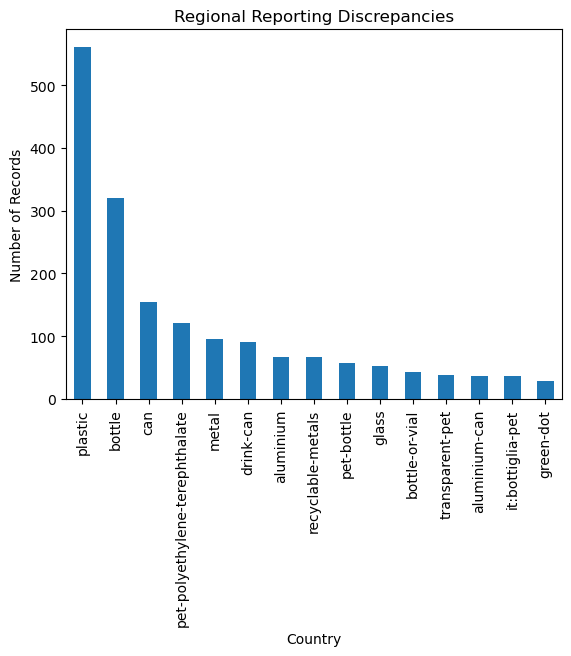

In [90]:
df_clean =cocacola.copy()
cocacola.value_counts("packaging_tags")
pack_df = df_clean.copy()
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.split(",")
pack_df = pack_df.explode("packaging_tags")
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.strip().str.lower()
pack_df["packaging_tags"].value_counts().head(15).plot(
    kind="bar",
    stacked=True)

plt.title("Regional Reporting Discrepancies")
plt.xlabel("Country")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.show()



### Observation
**Background:** Packaging information is used to understand the physical packaging associated with products. The column was split into individual packaging tags so multiple packaging descriptors could be counted separately.

**Finding:** `unknown` is the largest packaging value with **3,721 records**, while `plastic` is the most common identified packaging material with **561 records**. Other identified forms include bottles, cans, PET, metal, and aluminium.

**What this means:** Plastic is the leading identifiable packaging type, but the dominant overall category is actually missing/unknown information.

**Why it matters for sectional analysis:** Packaging conclusions should be described as conclusions about **recorded packaging data**, not the complete physical packaging profile of the portfolio. The high unknown count limits confidence in environmental or packaging comparisons.


### Brand: Fairlife

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Fanta

#### 5.1 Material Preferences by Territory

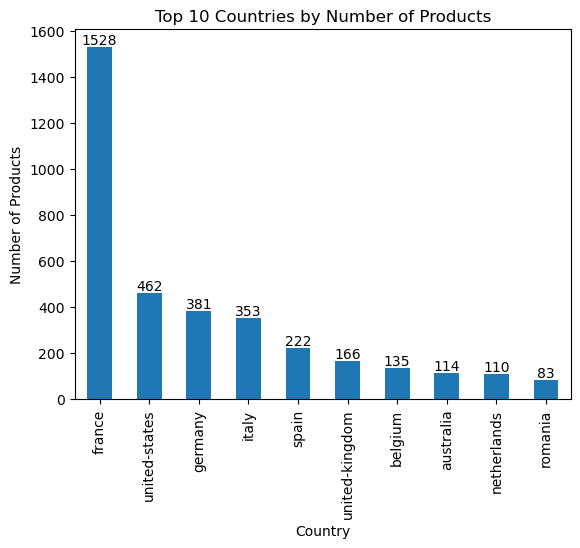

In [91]:
df_clean = fanta['countries_tags'].str.split(',')
df_clean = df_clean.explode("countries_tags")

df_clean = df_clean.str.strip()

df_clean = df_clean[df_clean != 'unknown']

df_clean.value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries by Number of Products')
plt.xlabel('Country')
plt.ylabel('Number of Products')
plt.xticks(rotation=90)
plt.bar_label(plt.gca().containers[0])

plt.show()

### Observation

- **France** has the highest number of products, with approximately **1,500+ products**.
- The **United States** ranks second with around **470 products**.
- **Germany** and **Italy** follow with approximately **400 and 370 products**, respectively.
- **Spain, United Kingdom, Belgium, Australia, Netherlands, and Romania** have comparatively fewer products.
- Overall, **France contributes significantly more products** than the other countries in the top 10.


#### 5.2 Regional Sustainability & Reporting Discrepancies

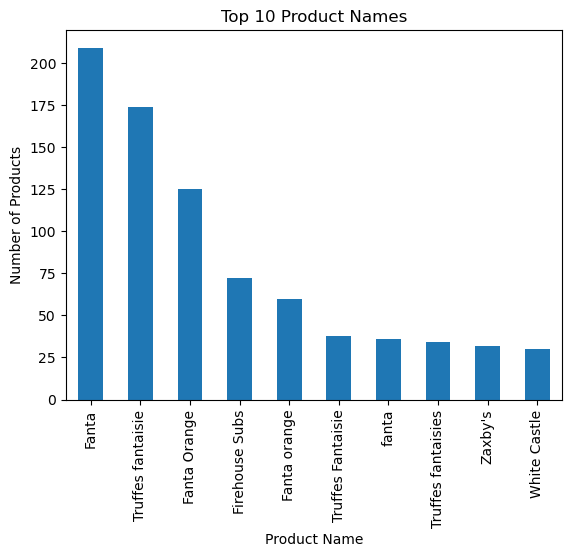

In [92]:
u_clean = fanta['product_name'].str.split(',').explode()

u_clean = u_clean.str.strip()


u_clean.value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Product Names')
plt.xlabel('Product Name')
plt.ylabel('Number of Products')
plt.xticks(rotation=90)

plt.show()

### Observation

- The chart displays the **Top 10 Product Categories** based on the number of products in the dataset.
- **Fanta** is the most represented category, with approximately **210 products**, followed by **Truffes Fantaisie** and **Fanta Orange**.
- The top three categories contribute a significantly larger number of products than the remaining categories.
- A sharp decline in product count is observed after the top three categories, indicating an uneven distribution of products.
- Categories such as **Firehouse Subs**, **Truffes Fantaisie**, **Zaxby's**, and **Orange** have comparatively lower product counts.
- Overall, the dataset is concentrated in a few dominant product categories, while the remaining categories have a much smaller presence.

### Brand: Maaza

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Minute Maid

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Schweppes

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Sprite

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Topo Chico

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

## Section 6: Limitations, Methodology & Strategic Conclusions